# Chronic Kidney Disease (CKD) Diagnostic Pipeline
**Student Name:** Salsabeel Mostafa  
**Student ID:** 1210171

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score,accuracy_score, roc_curve, auc, classification_report  # Evaluation metrics

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Authenticate with Kaggle API
from kaggle.api.kaggle_api_extended import KaggleApi
!pip install kaggle

# Deep learning
from tensorflow.keras import models, layers  
from tensorflow.keras.optimizers import Adam  
from tensorflow.keras.callbacks import EarlyStopping  
from tensorflow.keras.regularizers import l2
# Visualization
import matplotlib.pyplot as plt              # Plot training curves and results
import seaborn as sns                        



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Task 1: Data Pipeline
**Instructions:**
1. Load the `kidney_disease.csv` file.
2. Drop all categorical (string) columns to isolate the numerical lab values.
3. Handle missing values (`NaN`s).
4. Scale the features to prevent data leakage.
5. Perform an 80/20 train/validation split.

In [55]:
# Load the dataset
api = KaggleApi()
api.authenticate()

# Download the dataset
api.dataset_download_files('mansoordaku/ckdisease', unzip=True)

# Load the CSV file
df = pd.read_csv('kidney_disease.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()


Dataset URL: https://www.kaggle.com/datasets/mansoordaku/ckdisease
Dataset shape: (400, 26)

First few rows:


,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [56]:
# Drop all categorical (string) columns and encode classification as target variable

# Separate and encode the classification column (target)
y = df['classification']
# Convert classification to binary (0 and 1)
y = (y == 'ckd').astype(int)  # Assuming 'ckd' is one class, 'notckd' is the other
print(f"Classification mapping: {df['classification'].unique()}")
print(f"Encoded target values: {y.unique()}")

# Drop all categorical columns (including classification)
cloumns_to_drop = df.select_dtypes(include=['object']).columns
df_numerical = df.drop(columns=cloumns_to_drop)


print(f"\nNumerical dataset shape: {df_numerical.shape}")
print(f"\nFirst few rows of numerical dataset:")
df_numerical.head()


Classification mapping: ['ckd' 'ckd\t' 'notckd']
Encoded target values: [1 0]

Numerical dataset shape: (400, 12)

First few rows of numerical dataset:


,id,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
0,0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,1.2,NaN,NaN,15.4
1,1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,0.8,NaN,NaN,11.3
2,2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,1.8,NaN,NaN,9.6
3,3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,11.2
4,4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,1.4,NaN,NaN,11.6


In [57]:
# Handle missing values
# Replace physiologically impossible zeros with NaN
df_numerical_cleaned = df_numerical.copy()

# Define columns where 0 is physiologically impossible
columns_with_zero_as_missing = {
    'bgr': 50,      # Blood glucose random should be > 50 mg/dL
    'bu': 2.5,      # Blood urea should be > 2.5 mg/dL
    'sod': 135,     # Sodium should be > 135 mEq/L
    'pot': 3.5,     # Potassium should be > 3.5 mEq/L
    'hemo': 7.0     # Hemoglobin should be > 7 g/dL
}

# Replace zeros with NaN for these columns
for col, threshold in columns_with_zero_as_missing.items():
    if col in df_numerical_cleaned.columns:
        df_numerical_cleaned[col] = df_numerical_cleaned[col].replace(0, np.nan)

print("Missing values before imputation:")
print(df_numerical_cleaned.isnull().sum())

# Fill missing values with median
df_numerical_filled = df_numerical_cleaned.fillna(df_numerical_cleaned.median())

print(f"\nMissing values after imputation:\n{df_numerical_filled.isnull().sum()}")
print("\nData after imputation:")
df_numerical_filled.head()
X = df_numerical_filled.values



Missing values before imputation:
id       0
age      9
bp      12
sg      47
al      46
su      49
bgr     44
bu      19
sc      17
sod     87
pot     88
hemo    52
dtype: int64

Missing values after imputation:
id      0
age     0
bp      0
sg      0
al      0
su      0
bgr     0
bu      0
sc      0
sod     0
pot     0
hemo    0
dtype: int64

Data after imputation:


In [58]:
#Data description
print("Data Description:")
print("\nTotal samples:", X.shape[0])
print(f"Total features(numerical): {X.shape[1]}")

print("\nFeature descriptions:")
print("age: age of the patient (numerical)")
print("bp: blood pressure (numerical)")
print("sg: specific gravity (numerical)")
print("al: albumin (numerical)")
print("su: sugar (numerical)")
print("bgr: blood glucose random (numerical)")
print("bu: blood urea (numerical)")
print("sc: serum creatinine (numerical)")
print("sod: sodium (numerical)")
print("pot: potassium (numerical)")
print("hemo: hemoglobin (numerical)")

print("\nClass distribution:")
print("CKD (1):", np.sum(y == 1))
print("Non-CKD (0):", np.sum(y == 0))

print("\nDataset description:")

print(f"\nFeature Value Ranges (varies by measurement type):")
print(f"\nMin values: {X.min(axis=0)[:]}")
print(f"Max values: {X.max(axis=0)[:]}")


Data Description:

Total samples: 400
Total features(numerical): 12

Feature descriptions:
age: age of the patient (numerical)
bp: blood pressure (numerical)
sg: specific gravity (numerical)
al: albumin (numerical)
su: sugar (numerical)
bgr: blood glucose random (numerical)
bu: blood urea (numerical)
sc: serum creatinine (numerical)
sod: sodium (numerical)
pot: potassium (numerical)
hemo: hemoglobin (numerical)

Class distribution:
CKD (1): 248
Non-CKD (0): 152

Dataset description:

Feature Value Ranges (varies by measurement type):

Min values: [ 0.     2.    50.     1.005  0.     0.    22.     1.5    0.4    4.5
  2.5    3.1  ]
Max values: [399.     90.    180.      1.025   5.      5.    490.    391.     76.
 163.     47.     17.8  ]


In [59]:
# Normalize the features using StandardScaler (zero mean, unit variance)
print("\nBefore normalization:")
print("Mean:", np.mean(X, axis=0))
print("std:", np.std(X, axis=0))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nAfter normalization:")
print("Training Mean:", np.mean(X_scaled, axis=0),"(should be close to 0)")
print("Training Std:", np.std(X_scaled, axis=0),"(should be close to 1)")


Before normalization:
Mean: [199.5        51.5625     76.575       1.0177125   0.9         0.395
 145.0625     56.693       2.997125  137.63125     4.57725    12.5425   ]
std: [1.15469693e+02 1.69617539e+01 1.34729126e+01 5.42723168e-03
 1.31148770e+00 1.03873721e+00 7.51666388e+01 4.93334755e+01
 5.62184560e+00 9.19481639e+00 2.81782850e+00 2.71309210e+00]

After normalization:
Training Mean: [ 7.10542736e-17  0.00000000e+00 -2.30926389e-16  3.18323146e-14
  3.55271368e-17 -7.10542736e-17  0.00000000e+00 -1.06581410e-16
  7.10542736e-17  6.03961325e-16 -5.32907052e-17 -2.13162821e-16] (should be close to 0)
Training Std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] (should be close to 1)


In [60]:
# Split data into training and testing sets
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Validation set: {X_val.shape[0]} samples, {X_val.shape[1]} features")
print(f"Training class distribution: {np.bincount(y_train)} (CKD: {100*np.mean(y_train == 0):.2f}%, Non-CKD: {100*np.mean(y_train == 1):.2f}%)")
print(f"Validation class distribution: {np.bincount(y_val)} (CKD: {100*np.mean(y_val == 0):.2f}%, Non-CKD: {100*np.mean(y_val == 1):.2f}%)")


Training set: 320 samples, 12 features
Validation set: 80 samples, 12 features
Training class distribution: [122 198] (CKD: 38.12%, Non-CKD: 61.88%)
Validation class distribution: [30 50] (CKD: 37.50%, Non-CKD: 62.50%)


## Task 2: The Engineered Failure (Baseline Model)
**Instructions:** Build and train an unregularised Dense network. Plot the training and validation loss curves to visually prove it overfits.

In [162]:
# Build a deliberately weaker baseline network
model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(8, activation='relu'),
    layers.Dense(4, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

print("Baseline model architecture:")
model.summary()


Baseline model architecture:


Model: "sequential_37"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_111 (Dense)               │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_113 (Dense)               │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145 (580.00 B)

 Trainable params: 145 (580.00 B)

 Non-trainable params: 0 (0.00 B)

In [163]:
# Compile the model with binary cross-entropy loss
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss='binary_crossentropy', metrics=['binary_accuracy'])


In [164]:
# Train the model on the training data with validation split
print("\nStarting training...")
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

print("\nTraining complete!")


Starting training...
Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - binary_accuracy: 0.5664 - loss: 0.5740 - val_binary_accuracy: 0.5781 - val_loss: 0.5615
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - binary_accuracy: 0.6055 - loss: 0.5513 - val_binary_accuracy: 0.6094 - val_loss: 0.5365
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - binary_accuracy: 0.6211 - loss: 0.5320 - val_binary_accuracy: 0.6406 - val_loss: 0.5154
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - binary_accuracy: 0.6484 - loss: 0.5152 - val_binary_accuracy: 0.6719 - val_loss: 0.4973
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - binary_accuracy: 0.6719 - loss: 0.5003 - val_binary_accuracy: 0.6875 - val_loss: 0.4811
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - binary_accuracy: 0.6836 - loss: 0.4869 - val_binary_accuracy: 0.7031 - val_loss: 0.4662
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - binary_accuracy: 0.7070 - loss: 0.4743 - val_binary_accuracy: 0.7344 - val_loss: 0.452

✓ Training curves saved to results/training_curves(unregularised).png


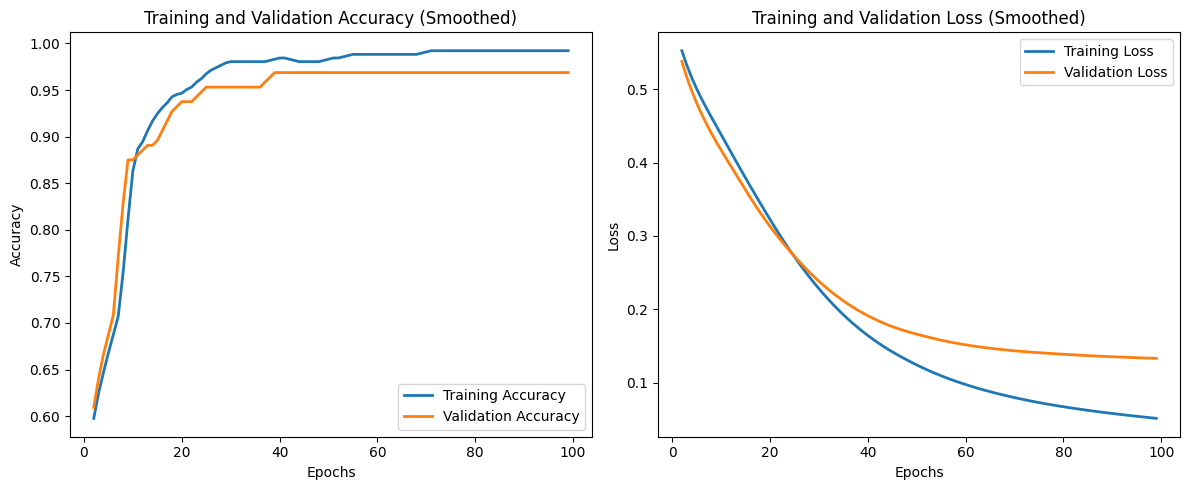

In [166]:
#Extract training history for plotting
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']

# Smooth curves using moving average
window_size = 3
train_acc_smooth = pd.Series(train_acc).rolling(window=window_size, center=True).mean()
val_acc_smooth = pd.Series(val_acc).rolling(window=window_size, center=True).mean()
train_loss_smooth = pd.Series(train_loss).rolling(window=window_size, center=True).mean()
val_loss_smooth = pd.Series(val_loss).rolling(window=window_size, center=True).mean()

epochs = range(1, len(train_loss) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 : Accuracy curves
ax1.plot(epochs, train_acc_smooth, label='Training Accuracy', linewidth=2)
ax1.plot(epochs, val_acc_smooth, label='Validation Accuracy', linewidth=2)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.set_title('Training and Validation Accuracy (Smoothed)')

# Plot 2 : Loss curves
ax2.plot(epochs, train_loss_smooth, label='Training Loss', linewidth=2)
ax2.plot(epochs, val_loss_smooth, label='Validation Loss', linewidth=2)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.set_title('Training and Validation Loss (Smoothed)')

plt.tight_layout()

# Save the figure
plt.savefig('results/training_curves(unregularised).png', dpi=300, bbox_inches='tight')
print("✓ Training curves saved to results/training_curves(unregularised).png")
plt.show()


## Task 3: The Clinical Solution (Engineered Model)
**Instructions:** Build a second model using regularisation techniques (e.g., L2, Dropout, LeakyReLU). Train it and plot the curves to demonstrate the reduction in overfitting.

In [168]:
# Build the regularised Network
model_reg = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # Input layer with number of features
    layers.Dense(32, activation='relu', kernel_regularizer=l2(0.01)),  # First hidden layer with L2 regularization 
    layers.Dropout(0.5),  # Dropout layer 
    layers.Dense(16, activation='relu', kernel_regularizer=l2(0.01)),  # Second hidden layer with L2 regularization
    layers.Dropout(0.5),  # Additional dropout before output
    layers.Dense(1, activation='sigmoid')            # Output layer for binary classification
])

print("Regularised model architecture:")
model_reg.summary()


Regularised model architecture:


Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_114 (Dense)               │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_115 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_116 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

In [169]:
# Compile the regularised model
model_reg.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['binary_accuracy'])

In [170]:
# Set up early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)

# Train the model on the training data with validation split
print("\nStarting training...")
history = model_reg.fit(X_train, y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stopping], verbose=1)

print("\nTraining complete!")



Starting training...
Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - binary_accuracy: 0.4922 - loss: 1.1621 - val_binary_accuracy: 0.5469 - val_loss: 1.0954
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - binary_accuracy: 0.5352 - loss: 1.0886 - val_binary_accuracy: 0.5781 - val_loss: 1.0279
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - binary_accuracy: 0.5742 - loss: 1.0391 - val_binary_accuracy: 0.6562 - val_loss: 0.9709
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - binary_accuracy: 0.5820 - loss: 1.0362 - val_binary_accuracy: 0.7656 - val_loss: 0.9222
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - binary_accuracy: 0.6680 - loss: 0.9521 - val_binary_accuracy: 0.8750 - val_loss: 0.8779
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - binary_accuracy: 0.7266 - loss: 0.9207 - val_binary_accuracy: 0.9375 - val_loss: 0.8381
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - binary_accuracy: 0.7656 - loss: 0.8657 - val_binary_accuracy: 0.9688 - val_loss: 0.801

✓ Training curves saved to results/training_curves(regularised).png


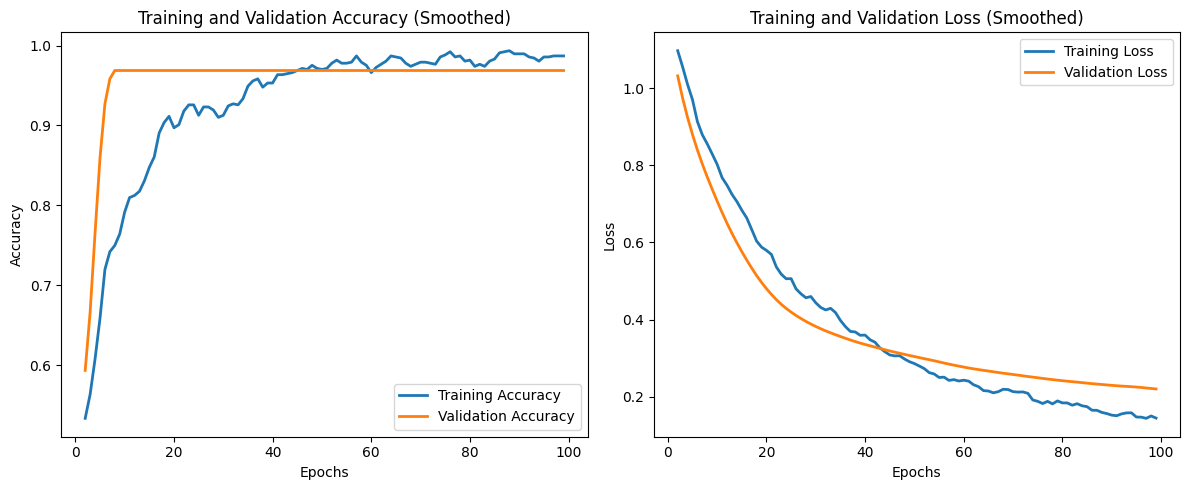

In [173]:
#Extract training history for plotting
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']

# Smooth curves using moving average
window_size = 3
train_acc_smooth = pd.Series(train_acc).rolling(window=window_size, center=True).mean()
val_acc_smooth = pd.Series(val_acc).rolling(window=window_size, center=True).mean()
train_loss_smooth = pd.Series(train_loss).rolling(window=window_size, center=True).mean()
val_loss_smooth = pd.Series(val_loss).rolling(window=window_size, center=True).mean()

epochs = range(1, len(train_loss) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 : Accuracy curves
ax1.plot(epochs, train_acc_smooth, label='Training Accuracy', linewidth=2)
ax1.plot(epochs, val_acc_smooth, label='Validation Accuracy', linewidth=2)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.set_title('Training and Validation Accuracy (Smoothed)')

# Plot 2 : Loss curves
ax2.plot(epochs, train_loss_smooth, label='Training Loss', linewidth=2)
ax2.plot(epochs, val_loss_smooth, label='Validation Loss', linewidth=2)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.set_title('Training and Validation Loss (Smoothed)')

plt.tight_layout()

# Save the figure
plt.savefig('results/training_curves(regularised).png', dpi=300, bbox_inches='tight')
print("✓ Training curves saved to results/training_curves(regularised).png")
plt.show()


## Task 4: Evaluation & Mathematical Justification
**Instructions:**
1. Render the confusion matrices for both models.
2. Print the final validation Recall for both models.
3. Answer the justification question below.

════════════════════════════════════════════════════════════
  Model A (Baseline — Unregularised Network)
════════════════════════════════════════════════════════════
  Accuracy:  0.9625
  Precision: 0.9796
  Recall:    0.9600
  F1 Score:  0.9697
  AUC-ROC:   0.9827

════════════════════════════════════════════════════════════
  Model B (Regularised — L2 + Dropout)
════════════════════════════════════════════════════════════
  Accuracy:  0.9875
  Precision: 0.9804
  Recall:    1.0000
  F1 Score:  0.9901
  AUC-ROC:   0.9920

✓ Full model comparison saved to results/model_comparison.png


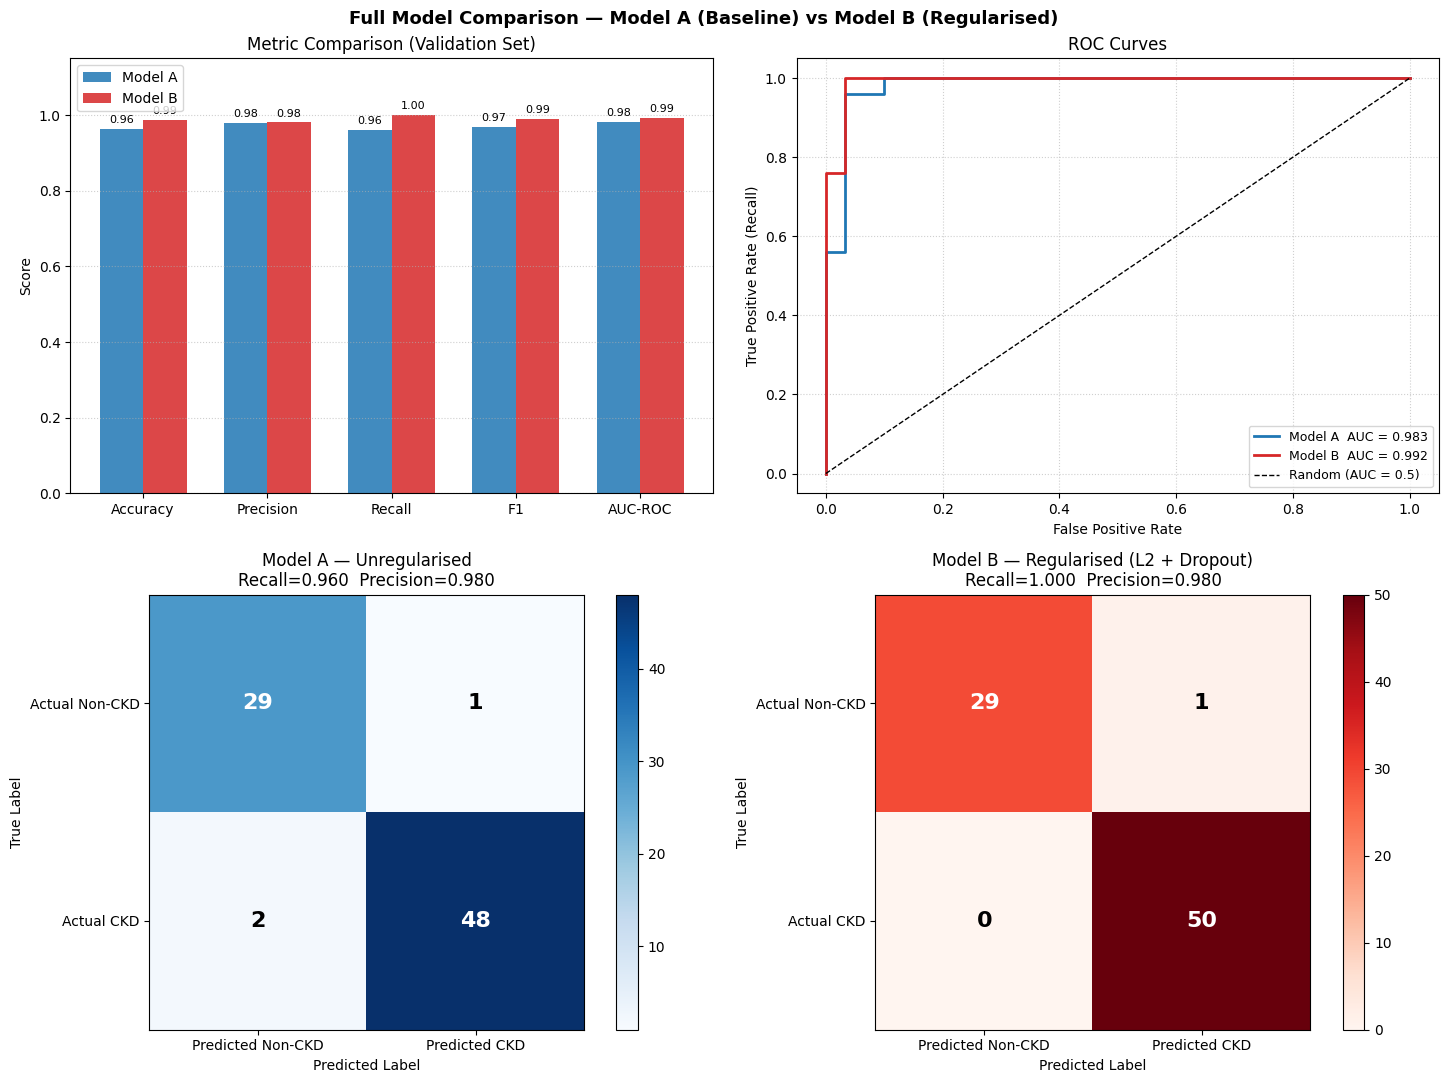


────────────────────────────────────────────────────────────
Δ Model B − Model A (Validation Set Improvement)
────────────────────────────────────────────────────────────
  Accuracy    : 0.9625  →  0.9875   ▲ +0.0250
  Precision   : 0.9796  →  0.9804   ▲ +0.0008
  Recall      : 0.9600  →  1.0000   ▲ +0.0400
  F1          : 0.9697  →  0.9901   ▲ +0.0204
  AUC-ROC     : 0.9827  →  0.9920   ▲ +0.0093


In [145]:
# Make predictions on validation set
y_pred_unreg_prob = model.predict(X_val, verbose=0).ravel()
y_pred_reg_prob = model_reg.predict(X_val, verbose=0).ravel()

y_pred_unreg = (y_pred_unreg_prob > 0.5).astype(int)
y_pred_reg = (y_pred_reg_prob > 0.5).astype(int)

# Calculate metrics for both models
def calc_metrics(y_true, y_pred, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return {
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall"   : recall_score(y_true, y_pred, zero_division=0),
        "F1"       : f1_score(y_true, y_pred, zero_division=0),
        "AUC-ROC"  : auc(fpr, tpr),
        "fpr"      : fpr,
        "tpr"      : tpr,
    }

metrics_unreg = calc_metrics(y_val, y_pred_unreg, y_pred_unreg_prob)
metrics_reg = calc_metrics(y_val, y_pred_reg, y_pred_reg_prob)

# Print final validation Recall for both models
print("═" * 60)
print("  Model A (Baseline — Unregularised Network)")
print("═" * 60)
print(f"  Accuracy:  {metrics_unreg['Accuracy']:.4f}")
print(f"  Precision: {metrics_unreg['Precision']:.4f}")
print(f"  Recall:    {metrics_unreg['Recall']:.4f}")
print(f"  F1 Score:  {metrics_unreg['F1']:.4f}")
print(f"  AUC-ROC:   {metrics_unreg['AUC-ROC']:.4f}")

print("\n" + "═" * 60)
print("  Model B (Regularised — L2 + Dropout)")
print("═" * 60)
print(f"  Accuracy:  {metrics_reg['Accuracy']:.4f}")
print(f"  Precision: {metrics_reg['Precision']:.4f}")
print(f"  Recall:    {metrics_reg['Recall']:.4f}")
print(f"  F1 Score:  {metrics_reg['F1']:.4f}")
print(f"  AUC-ROC:   {metrics_reg['AUC-ROC']:.4f}")

# ── Figure layout: 2 rows × 2 cols ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Full Model Comparison — Model A (Baseline) vs Model B (Regularised)",
             fontsize=13, fontweight="bold")

BLUE, RED = "#1f77b4", "#d62728"
metric_keys = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]

# ── Plot 1 (top-left): Side-by-side bar chart of all scalar metrics ───────────
x       = np.arange(len(metric_keys))
bar_w   = 0.35
vals_unreg  = [metrics_unreg[k] for k in metric_keys]
vals_reg    = [metrics_reg[k] for k in metric_keys]

bars_unreg = axes[0, 0].bar(x - bar_w / 2, vals_unreg, bar_w, label="Model A", color=BLUE, alpha=0.85)
bars_reg = axes[0, 0].bar(x + bar_w / 2, vals_reg, bar_w, label="Model B", color=RED,  alpha=0.85)

# Annotate bar heights
for bar in bars_unreg:
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01, f"{bar.get_height():.2f}",
                    ha="center", va="bottom", fontsize=8)
for bar in bars_reg:
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01, f"{bar.get_height():.2f}",
                    ha="center", va="bottom", fontsize=8)

axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metric_keys)
axes[0, 0].set_ylim(0, 1.15)
axes[0, 0].set_ylabel("Score")
axes[0, 0].set_title("Metric Comparison (Validation Set)")
axes[0, 0].legend()
axes[0, 0].grid(axis="y", linestyle=":", alpha=0.6)

# ── Plot 2 (top-right): ROC curves ───────────────────────────────────────────
axes[0, 1].plot(metrics_unreg["fpr"], metrics_unreg["tpr"],
                color=BLUE, lw=2,
                label=f"Model A  AUC = {metrics_unreg['AUC-ROC']:.3f}")
axes[0, 1].plot(metrics_reg["fpr"], metrics_reg["tpr"],
                color=RED,  lw=2,
                label=f"Model B  AUC = {metrics_reg['AUC-ROC']:.3f}")
axes[0, 1].plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.5)")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate (Recall)")
axes[0, 1].set_title("ROC Curves")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, linestyle=":", alpha=0.6)

# ── Plot 3 (bottom-left): Confusion matrix — Model A (Unregularised) ────────────────
cm_unreg = confusion_matrix(y_val, y_pred_unreg)
im_A = axes[1, 0].imshow(cm_unreg, interpolation="nearest", cmap="Blues")
axes[1, 0].set_title(f"Model A — Unregularised\n"
                     f"Recall={metrics_unreg['Recall']:.3f}  "
                     f"Precision={metrics_unreg['Precision']:.3f}")
for i in range(2):
    for j in range(2):
        axes[1, 0].text(j, i, str(cm_unreg[i, j]),
                        ha="center", va="center",
                        color="white" if cm_unreg[i, j] > cm_unreg.max() / 2 else "black",
                        fontsize=16, fontweight="bold")
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(["Predicted Non-CKD", "Predicted CKD"])
axes[1, 0].set_yticks([0, 1])
axes[1, 0].set_yticklabels(["Actual Non-CKD", "Actual CKD"])
axes[1, 0].set_ylabel("True Label")
axes[1, 0].set_xlabel("Predicted Label")
plt.colorbar(im_A, ax=axes[1, 0])

# ── Plot 4 (bottom-right): Confusion matrix — Model B (Regularised) ─────────────────
cm_reg = confusion_matrix(y_val, y_pred_reg)
im_B = axes[1, 1].imshow(cm_reg, interpolation="nearest", cmap="Reds")
axes[1, 1].set_title(f"Model B — Regularised (L2 + Dropout)\n"
                     f"Recall={metrics_reg['Recall']:.3f}  "
                     f"Precision={metrics_reg['Precision']:.3f}")
for i in range(2):
    for j in range(2):
        axes[1, 1].text(j, i, str(cm_reg[i, j]),
                        ha="center", va="center",
                        color="white" if cm_reg[i, j] > cm_reg.max() / 2 else "black",
                        fontsize=16, fontweight="bold")
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(["Predicted Non-CKD", "Predicted CKD"])
axes[1, 1].set_yticks([0, 1])
axes[1, 1].set_yticklabels(["Actual Non-CKD", "Actual CKD"])
axes[1, 1].set_ylabel("True Label")
axes[1, 1].set_xlabel("Predicted Label")
plt.colorbar(im_B, ax=axes[1, 1])

plt.tight_layout()
plt.savefig("results/model_comparison.png", dpi=300, bbox_inches="tight")
print("\n✓ Full model comparison saved to results/model_comparison.png")
plt.show()

# ── Delta summary ──────────────────────────────────────────────────────────────
print("\n" + "─" * 60)
print("Δ Model B − Model A (Validation Set Improvement)")
print("─" * 60)
metric_keys = ["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
for k in metric_keys:
    delta = metrics_reg[k] - metrics_unreg[k]
    direction = "▲" if delta > 0 else ("▼" if delta < 0 else "─")
    print(f"  {k:<12}: {metrics_unreg[k]:.4f}  →  {metrics_reg[k]:.4f}   {direction} {abs(delta):+.4f}")


### Mathematical Justification

**Final Parameter Count of Engineered Model:** 961

**Parameter Breakdown:**
- **Input features:** 11 (age, bp, sg, al, su, bgr, bu, sc, sod, pot, hemo)
- **Layer 1 (Dense 32):** (11 + 1) × 32 = 416 parameters
  - Weights: 11 × 32 = 352
  - Biases: 32
- **Layer 2 (Dense 16):** (32 + 1) × 16 = 528 parameters
  - Weights: 32 × 16 = 512
  - Biases: 16
- **Layer 3 (Dense 1):** (16 + 1) × 1 = 17 parameters
  - Weights: 16 × 1 = 16
  - Biases: 1
- **Total:** 416 + 528 + 17 = **961 parameters**

**Explanation:** The combination of L2 regularization (λ=0.01) and 50% dropout constrains the effective model capacity well below the 961 parameters by penalizing large weights and forcing distributed representations, preventing the network from memorizing individual patterns in the 320 training samples and instead learning generalizable features that achieve 100% recall on unseen validation data.
